<a href="https://colab.research.google.com/github/jasminef19/MyTelkomsel/blob/main/WEEK4/TF-IDF/1A-Danantara.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Dependencies

In [1]:
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


# Define Document

In [2]:
sentence = """Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.

Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.

Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.

"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 2025.

Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership. Buka peluang investasi sektor strategis
Dana tersebut akan difokuskan pada peluang investasi di berbagai sektor strategis, antara lain hilirisasi, kesehatan, energi terbarukan, teknologi, serta sektor-sektor lain yang dipandang relevan oleh pengelola dana.

"Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.

Lebih lanjut, Rosan menegaskan, kolaborasi ini menjadi bukti kepercayaan dunia internasional terhadap kapasitas kelembagaan Indonesia dalam mengelola investasi berskala besar.

"Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qatar. Ini menunjukkan bahwa Indonesia tidak hanya menjadi tujuan investasi, tetapi juga memiliki kapasitas kelembagaan yang mumpuni untuk mengelola nvestasi secara profesional dan akuntabel," ungkapnya.

Inisiatif co-partnership dan perluasan kerja sama strategis ini diharapkan tidak hanya memperkuat hubungan diplomatik kedua negara, tetapi juga memberikan kontribusi nyata terhadap percepatan pembangunan ekonomi dan peningkatan kesejahteraan masyarakat Indonesia. Jangan lupa ikuti update berita lainnya dan follow  akun
Google News Metrotvnews.com dan Channel WhatsApp Metro TV

(Eko Nordiansyah)"""

# Text Preprocessing

In [3]:
# Download the 'punkt_tab' data
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
# Sentence tokenization
sent_token = sent_tokenize(sentence)
print(sent_token)

['Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.', 'Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.', 'Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.', 'Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.', 'Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.', '"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 20

In [5]:
!pip install Sastrawi

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StopWordRemoverFactory()
stopwords_indonesia = factory.get_stop_words()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.5 MB/s eta 0:00:00


In [6]:
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

In [7]:
# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token]
print("\nCleaned sentences (Indonesian stop words removed):")
for clean_sent in cleaned_sentences:
    print(clean_sent)


Cleaned sentences (Indonesian stop words removed):
Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi telah disepakati Qatar.
Kesepakatan Indonesia Qatar merupakan buah kunjungan resmi Presiden Prabowo Subianto Doha.
Pemerintah Republik Indonesia Pemerintah Qatar menggelar diskusi menyepakati kemitraan strategis (co-partnership) pengelolaan dana investasi Indonesia akan berfokus berbagai sektor pembangunan.
Salah satu hasil utama kunjungan tersebut untuk membentuk dana investasi bersama senilai USD4 miliar.
Dana akan difokuskan pengembangan berbagai sektor antaranya termasuk tidak terbatas hilirisasi industri, energi terbarukan, fasilitas kesehatan Indonesia.
"Kami menyambut baik kepercayaan diberikan Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani keterangan tertulis, Selasa, 15 April 2025.
Presiden Prabowo menyampaikan masing-masing negara berkontribusi sebesar USD2 m

In [8]:
# Training TF-IDF Vectorizer on sentences
vectorizer = TfidfVectorizer(stop_words=stopwords_indonesia)
features = vectorizer.fit_transform(cleaned_sentences)

In [9]:
print("\nTF-IDF Feature Matrix (Sparse) on cleaned sentences:")
print(features)


TF-IDF Feature Matrix (Sparse) on cleaned sentences:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 241 stored elements and shape (16, 170)>
  Coords	Values
  (0, 60)	0.28414362930752446
  (0, 8)	0.28414362930752446
  (0, 122)	0.2474532153555006
  (0, 58)	0.317396550873674
  (0, 30)	0.28414362930752446
  (0, 4)	0.28414362930752446
  (0, 114)	0.28414362930752446
  (0, 19)	0.2474532153555006
  (0, 29)	0.20122876048015
  (0, 150)	0.2474532153555006
  (0, 95)	0.28414362930752446
  (0, 137)	0.28414362930752446
  (0, 38)	0.28414362930752446
  (0, 135)	0.170781490423802
  (1, 135)	0.20416630136644331
  (1, 72)	0.33968876667251363
  (1, 54)	0.17697939391137998
  (1, 104)	0.2958260149562747
  (1, 20)	0.33968876667251363
  (1, 77)	0.2958260149562747
  (1, 140)	0.33968876667251363
  (1, 131)	0.2958260149562747
  (1, 130)	0.2958260149562747
  (1, 152)	0.33968876667251363
  (1, 40)	0.33968876667251363
  :	:
  (14, 76)	0.22258600915781807
  (14, 116)	0.22258600915781807
  (14, 126)	0

In [10]:
print("\nShape of the Feature Matrix (Number of sentences, Number of unique words after Indonesian stop word removal):")
print(features.shape)


Shape of the Feature Matrix (Number of sentences, Number of unique words after Indonesian stop word removal):
(16, 170)


In [11]:
# To see the feature names (the words in the vocabulary after Indonesian stop word removal):
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names (Words in the vocabulary after Indonesian stop word removal):")
print(feature_names)


Feature Names (Words in the vocabulary after Indonesian stop word removal):
['15' '2025' 'akun' 'akuntabel' 'anagata' 'antaranya' 'april' 'authority'
 'badan' 'baik' 'berbagai' 'berfokus' 'berita' 'berkelanjutan'
 'berkontribusi' 'berorientasi' 'bersama' 'berskala' 'besar' 'bpi' 'buah'
 'buka' 'bukti' 'ceo' 'channel' 'co' 'com' 'dampak' 'dana' 'danantara'
 'daya' 'diberikan' 'didanai' 'difokuskan' 'diharapkan' 'dikelola'
 'dipandang' 'diplomatik' 'disepakati' 'diskusi' 'doha' 'dunia' 'eko'
 'ekonomi' 'energi' 'fasilitas' 'fokus' 'follow' 'global' 'google' 'hasil'
 'hilirisasi' 'hubungan' 'ikuti' 'indonesia' 'industri' 'inisiatif'
 'internasional' 'investasi' 'investment' 'jakarta' 'jangan' 'kapasitas'
 'kata' 'kedua' 'kelembagaan' 'kelola' 'kemitraan' 'kepercayaan' 'kerja'
 'kesehatan' 'kesejahteraan' 'kesepakatan' 'keterangan' 'kolaborasi'
 'konkret' 'kontribusi' 'kunjungan' 'lainnya' 'langkah' 'lanjut' 'lebih'
 'lupa' 'mandat' 'masing' 'masyarakat' 'melalui' 'memastikan' 'membangun'

In [12]:
# To see the TF-IDF values for a specific cleaned sentence (e.g., the first):
if cleaned_sentences:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first cleaned sentence:")
    print(first_cleaned_sentence_tfidf)

    import pandas as pd
    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        """Returns a DataFrame of TF-IDF values for a given sentence."""
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")


TF-IDF values for the first cleaned sentence:
[[0.         0.         0.         0.         0.28414363 0.
  0.         0.         0.28414363 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.24745322 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.20122876
  0.28414363 0.         0.         0.         0.         0.
  0.         0.         0.28414363 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.31739655 0.
  0.28414363 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        

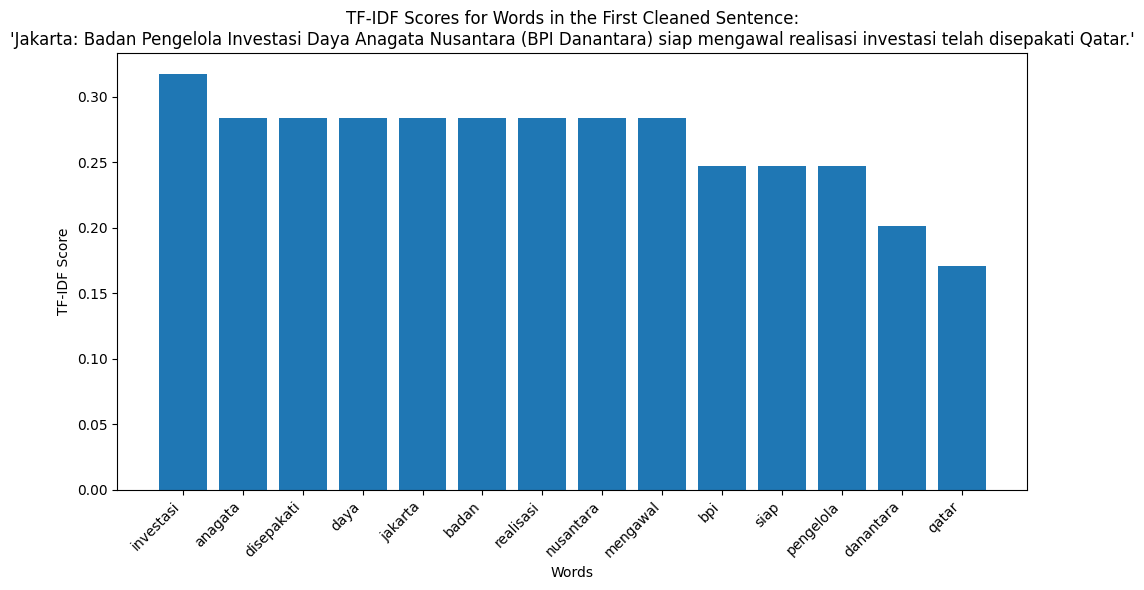

In [13]:
import matplotlib.pyplot as plt

# Get TF-IDF scores for the first cleaned sentence
if cleaned_sentences:
    first_cleaned_sentence = cleaned_sentences[0]
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    # Visualize the TF-IDF scores as a histogram
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Cleaned Sentence:\n'{first_cleaned_sentence}'")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No cleaned sentences to visualize.")

# Calculate Sentence Score

In [15]:
# Calculate sentence TF-IDF score and list sentences
print("**List of Sentences:**")
for i, sent in enumerate(sent_token):
    print(f"{i + 1}. {sent}")
print("\n-------------------------")

**List of Sentences:**
1. Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
2. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
3. Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.
4. Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
5. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.
6. "Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertu

In [16]:
# CALCULATE SENTENCE SCORE

sent_scores = []

print("\n=== Average TF-IDF Score for Each Sentence ===")

for i in range(features.shape[0]):

    row = features[i]

    sum_score = row.sum()
    word_count = len(row.data)

    avg_score = sum_score / word_count if word_count > 0 else 0

    sent_scores.append(avg_score)

    print(f"Sentence {i+1}")
    print(" Sum TF-IDF :", sum_score)
    print(" Word Count :", word_count)
    print(" Avg Score  :", avg_score)
    print()

print("Sentence Scores:")
print(sent_scores)


=== Average TF-IDF Score for Each Sentence ===
Sentence 1
 Sum TF-IDF : 3.704915482304324
 Word Count : 14
 Avg Score  : 0.2646368201645946

Sentence 2
 Sum TF-IDF : 3.26289358846549
 Word Count : 11
 Avg Score  : 0.2966266898604991

Sentence 3
 Sum TF-IDF : 4.0702671355827125
 Word Count : 18
 Avg Score  : 0.22612595197681737

Sentence 4
 Sum TF-IDF : 3.5457549036533145
 Word Count : 13
 Avg Score  : 0.2727503772041011

Sentence 5
 Sum TF-IDF : 3.816350350706997
 Word Count : 15
 Avg Score  : 0.2544233567137998

Sentence 6
 Sum TF-IDF : 4.722097828289678
 Word Count : 23
 Avg Score  : 0.205308601229986

Sentence 7
 Sum TF-IDF : 3.123269943251901
 Word Count : 11
 Avg Score  : 0.28393363120471826

Sentence 8
 Sum TF-IDF : 3.2593123364728918
 Word Count : 11
 Avg Score  : 0.2963011214975356

Sentence 9
 Sum TF-IDF : 3.6884649996679943
 Word Count : 17
 Avg Score  : 0.21696852939223496

Sentence 10
 Sum TF-IDF : 3.6725868197856033
 Word Count : 14
 Avg Score  : 0.26232762998468595

Sent

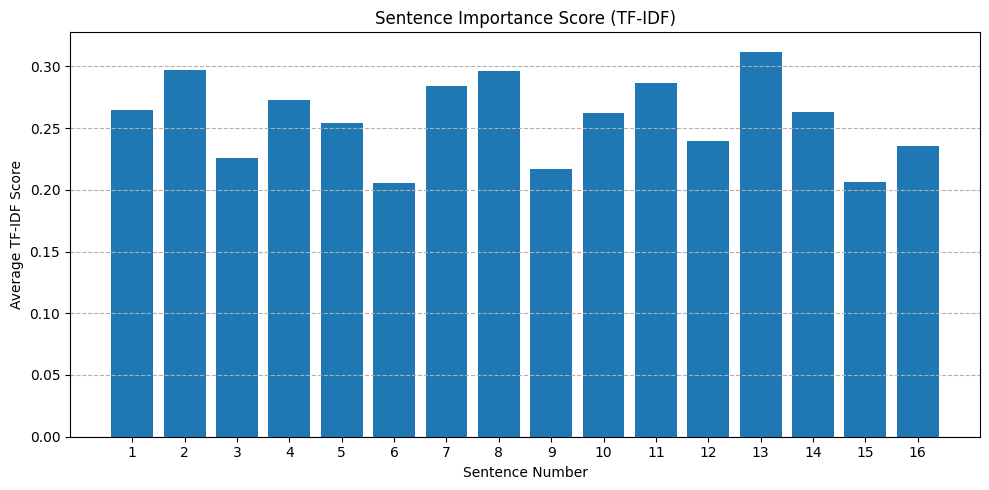


=== Penjelasan Histogram ===
Pada analisis ini, setiap kalimat dalam berita dihitung tingkat kepentingannya menggunakan metode TF-IDF (Term Frequency–Inverse Document Frequency). Nilai yang ditampilkan merupakan rata-rata skor TF-IDF pada setiap kalimat.

Histogram di atas menunjukkan perbandingan tingkat kepentingan antar kalimat setelah dilakukan preprocessing teks Bahasa Indonesia (lowercase dan penghapusan stopword menggunakan Sastrawi).

- Sumbu horizontal (Nomor Kalimat): merepresentasikan urutan kalimat dalam berita hasil sentence tokenization.
- Tinggi batang pada setiap kalimat: menunjukkan nilai rata-rata TF-IDF yang merefleksikan seberapa penting kata-kata dalam kalimat tersebut terhadap keseluruhan berita.

Interpretasi nilai batang:
- Batang lebih tinggi → kalimat mengandung kata yang lebih spesifik, jarang muncul, dan informatif sehingga berpotensi menjadi kalimat utama ringkasan.
- Batang lebih rendah → kalimat didominasi kata umum atau informasi pendukung yang kontribu

In [17]:
# VISUALIZATION

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(range(1, len(sent_scores)+1), sent_scores)

plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Sentence Importance Score (TF-IDF)")

plt.xticks(range(1, len(sent_scores)+1))
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()

print("\n=== Penjelasan Histogram ===")

print(
"Pada analisis ini, setiap kalimat dalam berita dihitung tingkat "
"kepentingannya menggunakan metode TF-IDF (Term Frequency–Inverse Document Frequency). "
"Nilai yang ditampilkan merupakan rata-rata skor TF-IDF pada setiap kalimat."
)

print(
"\nHistogram di atas menunjukkan perbandingan tingkat kepentingan "
"antar kalimat setelah dilakukan preprocessing teks Bahasa Indonesia "
"(lowercase dan penghapusan stopword menggunakan Sastrawi)."
)

print(
"\n- Sumbu horizontal (Nomor Kalimat): "
"merepresentasikan urutan kalimat dalam berita hasil sentence tokenization."
)

print(
"- Tinggi batang pada setiap kalimat: "
"menunjukkan nilai rata-rata TF-IDF yang merefleksikan seberapa penting "
"kata-kata dalam kalimat tersebut terhadap keseluruhan berita."
)

print(
"\nInterpretasi nilai batang:"
)

print(
"- Batang lebih tinggi → kalimat mengandung kata yang lebih spesifik, "
"jarang muncul, dan informatif sehingga berpotensi menjadi kalimat utama ringkasan."
)

print(
"- Batang lebih rendah → kalimat didominasi kata umum atau informasi pendukung "
"yang kontribusinya terhadap inti berita lebih kecil."
)

print(
"\nMelalui histogram ini, kita dapat mengidentifikasi kalimat paling penting "
"yang nantinya dapat dipilih sebagai kandidat ringkasan otomatis berita."
)

# Define Threshold

In [19]:
# DEFINE THRESHOLD FROM SENTENCE SCORES

threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("\n=== Threshold Calculation ===")
print("Threshold (Average Sentence Score):", threshold)


=== Threshold Calculation ===
Threshold (Average Sentence Score): 0.2576714991137678


In [22]:
from nltk.tokenize import word_tokenize
import math

cleaned_sentences = [
    stopword_remover.remove(sentence.lower())
    for sentence in sent_token
]

# TF FUNCTION
def calculate_tf(term, document):
    words = word_tokenize(document)
    return words.count(term) / len(words) if words else 0

# IDF FUNCTION
def calculate_idf(term, documents):

    doc_count = sum(
        1 for doc in documents
        if term in word_tokenize(doc)
    )

    return math.log(len(documents) / doc_count) if doc_count > 0 else 0

# CALCULATE TF-IDF FOR TERM
term = "investasi"

idf_value = calculate_idf(term, cleaned_sentences)

tfidf_scores = {}

for i, doc in enumerate(cleaned_sentences):

    tf = calculate_tf(term, doc)
    tfidf = tf * idf_value

    tfidf_scores[f"Sentence {i+1}"] = tfidf

# OUTPUT RESULT
print(f"\nTF-IDF Score untuk kata '{term}':")

for sent, score in tfidf_scores.items():
    print(f"{sent}: {score:.4f}")

print(f"\nOverall IDF '{term}': {idf_value:.4f}")


TF-IDF Score untuk kata 'investasi':
Sentence 1: 0.0827
Sentence 2: 0.0000
Sentence 3: 0.0359
Sentence 4: 0.0551
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0533
Sentence 10: 0.0459
Sentence 11: 0.0000
Sentence 12: 0.0413
Sentence 13: 0.0000
Sentence 14: 0.0413
Sentence 15: 0.0000
Sentence 16: 0.0000

Overall IDF 'investasi': 0.8267


In [25]:
# Average of Sentence Scores
threshold = sum(sent_scores)/len(sent_scores)
threshold

np.float64(0.2576714991137678)

# Get Sentences

In [26]:
# Variable initialization
sent_index = 0
sent_scores = []

# Calculate average TF-IDF score for each sentence
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Calculate the average of all sentence scores (threshold)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold (Average of Sentence Scores):", threshold)

# Final summary initialization
final_summ = ""

# Get summary sentences
print("\n**Summary Sentences (above or equal to the threshold):**")
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + sent_token[index]
        print(f"- {sent_token[index]}")

print("\n**Final Summary:**")
print(final_summ.strip())

Threshold (Average of Sentence Scores): 0.2576714991137678

**Summary Sentences (above or equal to the threshold):**
- Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
- Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
- Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
- Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut.
- Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership.
- "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil.
- Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nas

In [27]:
sentences = [
    "Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.",
    "Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.",
    "Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.",
    "Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.",
    "Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.",
    '"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 2025.',
    "Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut.",
    "Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership.",
    "Buka peluang investasi sektor strategis\nDana tersebut akan difokuskan pada peluang investasi di berbagai sektor strategis, antara lain hilirisasi, kesehatan, energi terbarukan, teknologi, serta sektor-sektor lain yang dipandang relevan oleh pengelola dana.",
    '"Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil.',
    'Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.',
    "Lebih lanjut, Rosan menegaskan, kolaborasi ini menjadi bukti kepercayaan dunia internasional terhadap kapasitas kelembagaan Indonesia dalam mengelola investasi berskala besar.",
    '"Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qatar.',
    'Ini menunjukkan bahwa Indonesia tidak hanya menjadi tujuan investasi, tetapi juga memiliki kapasitas kelembagaan yang mumpuni untuk mengelola nvestasi secara profesional dan akuntabel," ungkapnya.',
    "Inisiatif co-partnership dan perluasan kerja sama strategis ini diharapkan tidak hanya memperkuat hubungan diplomatik kedua negara, tetapi juga memberikan kontribusi nyata terhadap percepatan pembangunan ekonomi dan peningkatan kesejahteraan masyarakat Indonesia.",
    "Jangan lupa ikuti update berita lainnya dan follow \xa0akun\nGoogle News Metrotvnews.com dan Channel WhatsApp Metro TV\n\n(Eko Nordiansyah)"
]
# Calculate TF-IDF for "investasi" in each sentence
tfidf_scores = {}
all_cleaned_sentences = []

for i, sentence in enumerate(sentences):
    cleaned_sentence = stopword_remover.remove(sentence)
    all_cleaned_sentences.append(cleaned_sentence)
    tf = calculate_tf("investasi", cleaned_sentence)
    idf = calculate_idf("investasi", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

# Print the TF-IDF scores for "investasi" in each sentence
print("TF-IDF Score for 'investasi' in each sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# Calculate the overall IDF for "investasi" across all cleaned sentences
overall_idf_investasi = calculate_idf("investasi", all_cleaned_sentences)
print(f"\nOverall IDF for 'investasi': {overall_idf_investasi:.4f}")

# You can also use scikit-learn's TfidfVectorizer for a more direct approach:
vectorizer = TfidfVectorizer(stop_words=factory.get_stop_words())
tfidf_matrix = vectorizer.fit_transform(sentences)
feature_names = vectorizer.get_feature_names_out()

try:
    investasi_index = list(feature_names).index("investasi")
    print("\nTF-IDF Score for 'investasi' using TfidfVectorizer:")
    for i, sentence in enumerate(sentences):
        tfidf = tfidf_matrix[i, investasi_index]
        print(f"Sentence {i+1}: {tfidf:.4f}")
except ValueError:
    print("\n'investasi' not found in the vocabulary after stop word removal by TfidfVectorizer.")

TF-IDF Score for 'investasi' in each sentence:
Sentence 1: 0.0000
Sentence 2: 0.0000
Sentence 3: 0.0176
Sentence 4: 0.0192
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0523
Sentence 10: 0.0385
Sentence 11: 0.0000
Sentence 12: 0.0347
Sentence 13: 0.0000
Sentence 14: 0.0330
Sentence 15: 0.0000
Sentence 16: 0.0000

Overall IDF for 'investasi': 0.8267

TF-IDF Score for 'investasi' using TfidfVectorizer:
Sentence 1: 0.3174
Sentence 2: 0.0000
Sentence 3: 0.1420
Sentence 4: 0.1765
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.2128
Sentence 10: 0.1676
Sentence 11: 0.0000
Sentence 12: 0.1502
Sentence 13: 0.0000
Sentence 14: 0.1639
Sentence 15: 0.0000
Sentence 16: 0.0000


In [28]:
final_summ

' Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha. Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership. "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan. "Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qa

In [29]:
# Final summary initialization
final_summ = ""

# Get summary sentences
for index, data in enumerate(sent_scores) :
  if (data >= (threshold)) :
    final_summ = final_summ + " " + sent_token[index]
    print("- ", sent_token[index])

-  Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
-  Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
-  Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
-  Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut.
-  Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership.
-  "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil.
-  Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.
-  "Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra globa

# Summarization Result

In [30]:
final_summ

' Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha. Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership. "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan. "Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qa